In [1]:

# imports
import os
import sys
import types
import json
import base64

# figure size/format
fig_width = 7
fig_height = 5
fig_format = 'retina'
fig_dpi = 96
interactivity = ''
is_shiny = False
is_dashboard = False
plotly_connected = True

# matplotlib defaults / format
try:
  import matplotlib.pyplot as plt
  plt.rcParams['figure.figsize'] = (fig_width, fig_height)
  plt.rcParams['figure.dpi'] = fig_dpi
  plt.rcParams['savefig.dpi'] = "figure"

  # IPython 7.14 deprecated set_matplotlib_formats from IPython
  try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
  except ImportError:
    # Fall back to deprecated location for older IPython versions
    from IPython.display import set_matplotlib_formats
    
  set_matplotlib_formats(fig_format)
except Exception:
  pass

# plotly use connected mode
try:
  import plotly.io as pio
  if plotly_connected:
    pio.renderers.default = "notebook_connected"
  else:
    pio.renderers.default = "notebook"
  for template in pio.templates.keys():
    pio.templates[template].layout.margin = dict(t=30,r=0,b=0,l=0)
except Exception:
  pass

# disable itables paging for dashboards
if is_dashboard:
  try:
    from itables import options
    options.dom = 'fiBrtlp'
    options.maxBytes = 1024 * 1024
    options.language = dict(info = "Showing _TOTAL_ entries")
    options.classes = "display nowrap compact"
    options.paging = False
    options.searching = True
    options.ordering = True
    options.info = True
    options.lengthChange = False
    options.autoWidth = False
    options.responsive = True
    options.keys = True
    options.buttons = []
  except Exception:
    pass
  
  try:
    import altair as alt
    # By default, dashboards will have container sized
    # vega visualizations which allows them to flow reasonably
    theme_sentinel = '_quarto-dashboard-internal'
    def make_theme(name):
        nonTheme = alt.themes._plugins[name]    
        def patch_theme(*args, **kwargs):
            existingTheme = nonTheme()
            if 'height' not in existingTheme:
              existingTheme['height'] = 'container'
            if 'width' not in existingTheme:
              existingTheme['width'] = 'container'

            if 'config' not in existingTheme:
              existingTheme['config'] = dict()
            
            # Configure the default font sizes
            title_font_size = 15
            header_font_size = 13
            axis_font_size = 12
            legend_font_size = 12
            mark_font_size = 12
            tooltip = False

            config = existingTheme['config']

            # The Axis
            if 'axis' not in config:
              config['axis'] = dict()
            axis = config['axis']
            if 'labelFontSize' not in axis:
              axis['labelFontSize'] = axis_font_size
            if 'titleFontSize' not in axis:
              axis['titleFontSize'] = axis_font_size  

            # The legend
            if 'legend' not in config:
              config['legend'] = dict()
            legend = config['legend']
            if 'labelFontSize' not in legend:
              legend['labelFontSize'] = legend_font_size
            if 'titleFontSize' not in legend:
              legend['titleFontSize'] = legend_font_size  

            # The header
            if 'header' not in config:
              config['header'] = dict()
            header = config['header']
            if 'labelFontSize' not in header:
              header['labelFontSize'] = header_font_size
            if 'titleFontSize' not in header:
              header['titleFontSize'] = header_font_size    

            # Title
            if 'title' not in config:
              config['title'] = dict()
            title = config['title']
            if 'fontSize' not in title:
              title['fontSize'] = title_font_size

            # Marks
            if 'mark' not in config:
              config['mark'] = dict()
            mark = config['mark']
            if 'fontSize' not in mark:
              mark['fontSize'] = mark_font_size

            # Mark tooltips
            if tooltip and 'tooltip' not in mark:
              mark['tooltip'] = dict(content="encoding")

            return existingTheme
            
        return patch_theme

    # We can only do this once per session
    if theme_sentinel not in alt.themes.names():
      for name in alt.themes.names():
        alt.themes.register(name, make_theme(name))
      
      # register a sentinel theme so we only do this once
      alt.themes.register(theme_sentinel, make_theme('default'))
      alt.themes.enable('default')

  except Exception:
    pass

# enable pandas latex repr when targeting pdfs
try:
  import pandas as pd
  if fig_format == 'pdf':
    pd.set_option('display.latex.repr', True)
except Exception:
  pass

# interactivity
if interactivity:
  from IPython.core.interactiveshell import InteractiveShell
  InteractiveShell.ast_node_interactivity = interactivity

# NOTE: the kernel_deps code is repeated in the cleanup.py file
# (we can't easily share this code b/c of the way it is run).
# If you edit this code also edit the same code in cleanup.py!

# output kernel dependencies
kernel_deps = dict()
for module in list(sys.modules.values()):
  # Some modules play games with sys.modules (e.g. email/__init__.py
  # in the standard library), and occasionally this can cause strange
  # failures in getattr.  Just ignore anything that's not an ordinary
  # module.
  if not isinstance(module, types.ModuleType):
    continue
  path = getattr(module, "__file__", None)
  if not path:
    continue
  if path.endswith(".pyc") or path.endswith(".pyo"):
    path = path[:-1]
  if not os.path.exists(path):
    continue
  kernel_deps[path] = os.stat(path).st_mtime
print(json.dumps(kernel_deps))

# set run_path if requested
run_path = 'QzpcVXNlcnNcbG9pY2hcRG9jdW1lbnRzXFdvcmtcR2l0aHViXHF1YXJ0b1xweXRob25faWFfcXVhcnRvXG1vZHVsZXNcbW9kdWxlXzAy'
if run_path:
  # hex-decode the path
  run_path = base64.b64decode(run_path.encode("utf-8")).decode("utf-8")
  os.chdir(run_path)

# reset state
%reset

# shiny
# Checking for shiny by using False directly because we're after the %reset. We don't want
# to set a variable that stays in global scope.
if False:
  try:
    import htmltools as _htmltools
    import ast as _ast

    _htmltools.html_dependency_render_mode = "json"

    # This decorator will be added to all function definitions
    def _display_if_has_repr_html(x):
      try:
        # IPython 7.14 preferred import
        from IPython.display import display, HTML
      except:
        from IPython.core.display import display, HTML

      if hasattr(x, '_repr_html_'):
        display(HTML(x._repr_html_()))
      return x

    # ideally we would undo the call to ast_transformers.append
    # at the end of this block whenver an error occurs, we do 
    # this for now as it will only be a problem if the user 
    # switches from shiny to not-shiny mode (and even then likely
    # won't matter)
    import builtins
    builtins._display_if_has_repr_html = _display_if_has_repr_html

    class _FunctionDefReprHtml(_ast.NodeTransformer):
      def visit_FunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

      def visit_AsyncFunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

    ip = get_ipython()
    ip.ast_transformers.append(_FunctionDefReprHtml())

  except:
    pass

def ojs_define(**kwargs):
  import json
  try:
    # IPython 7.14 preferred import
    from IPython.display import display, HTML
  except:
    from IPython.core.display import display, HTML

  # do some minor magic for convenience when handling pandas
  # dataframes
  def convert(v):
    try:
      import pandas as pd
    except ModuleNotFoundError: # don't do the magic when pandas is not available
      return v
    if type(v) == pd.Series:
      v = pd.DataFrame(v)
    if type(v) == pd.DataFrame:
      j = json.loads(v.T.to_json(orient='split'))
      return dict((k,v) for (k,v) in zip(j["index"], j["data"]))
    else:
      return v

  v = dict(contents=list(dict(name=key, value=convert(value)) for (key, value) in kwargs.items()))
  display(HTML('<script type="ojs-define">' + json.dumps(v) + '</script>'), metadata=dict(ojs_define = True))
globals()["ojs_define"] = ojs_define
globals()["__spec__"] = None

{"C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\importlib\\_bootstrap.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\importlib\\_bootstrap_external.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\zipimport.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\codecs.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\encodings\\aliases.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\encodings\\__init__.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\encodings\\utf_8.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\encodings\\cp1252.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\abc.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python

In [2]:
#| label: setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_columns', 20)

print(f"✅ Pandas {pd.__version__}")
print(f"✅ NumPy  {np.__version__}")

✅ Pandas 3.0.2
✅ NumPy  2.2.6


In [3]:
# Créer une Series
ventes_par_mois = pd.Series(
    [120, 150, 180, 210, 190, 220, 300, 280, 240, 260, 350, 400],
    index=["Jan", "Fév", "Mar", "Avr", "Mai", "Juin", 
           "Juil", "Août", "Sep", "Oct", "Nov", "Déc"],
    name="ventes_mensuelles"
)
print(ventes_par_mois)

Jan     120
Fév     150
Mar     180
Avr     210
Mai     190
Juin    220
Juil    300
Août    280
Sep     240
Oct     260
Nov     350
Déc     400
Name: ventes_mensuelles, dtype: int64


In [4]:
print(f"Moyenne : {ventes_par_mois.mean():.1f}")
print(f"Ventes en juin : {ventes_par_mois['Juin']}")
print(f"\nMois où on a dépassé 250 :")
print(ventes_par_mois[ventes_par_mois > 250])

Moyenne : 241.7
Ventes en juin : 220

Mois où on a dépassé 250 :
Juil    300
Août    280
Oct     260
Nov     350
Déc     400
Name: ventes_mensuelles, dtype: int64


In [5]:
# Créer un DataFrame depuis un dictionnaire
df = pd.DataFrame({
    "ville": ["Paris", "Lyon", "Marseille", "Bordeaux", "Lille"],
    "population": [2_148_000, 513_000, 862_000, 254_000, 232_000],
    "surface_km2": [105, 48, 240, 49, 35],
    "region": ["IDF", "ARA", "PACA", "NAQ", "HDF"]
})

print(df)

       ville  population  surface_km2 region
0      Paris     2148000          105    IDF
1       Lyon      513000           48    ARA
2  Marseille      862000          240   PACA
3   Bordeaux      254000           49    NAQ
4      Lille      232000           35    HDF


In [6]:
# Calculer une nouvelle colonne (densité)
df["densite"] = df["population"] / df["surface_km2"]
df["densite"] = df["densite"].round(0).astype(int)
print(df)

       ville  population  surface_km2 region  densite
0      Paris     2148000          105    IDF    20457
1       Lyon      513000           48    ARA    10688
2  Marseille      862000          240   PACA     3592
3   Bordeaux      254000           49    NAQ     5184
4      Lille      232000           35    HDF     6629


In [7]:
#| eval: false
# TODO: Exercice 1

# 1. Series de températures


# 2. Stats


# 3. DataFrame employés


# 4. Colonne salaire annuel


# 5. Filtrer IT

In [8]:
# 1-2. Series de températures
temp = pd.Series(
    [18, 20, 22, 19, 17, 23, 25],
    index=["Lun", "Mar", "Mer", "Jeu", "Ven", "Sam", "Dim"],
    name="temperature_C"
)
print(temp)
print(f"\nMoyenne : {temp.mean():.1f}°C")
print(f"Min     : {temp.min()}°C (le {temp.idxmin()})")
print(f"Max     : {temp.max()}°C (le {temp.idxmax()})")

Lun    18
Mar    20
Mer    22
Jeu    19
Ven    17
Sam    23
Dim    25
Name: temperature_C, dtype: int64

Moyenne : 20.6°C
Min     : 17°C (le Ven)
Max     : 25°C (le Dim)


In [9]:
# 3-5. DataFrame employés
df = pd.DataFrame({
    "nom": ["Alice", "Bob", "Claire", "David", "Emma"],
    "age": [28, 45, 33, 52, 29],
    "salaire": [3200, 4800, 3500, 5200, 2900],
    "departement": ["IT", "RH", "IT", "Finance", "IT"]
})

df["salaire_annuel"] = df["salaire"] * 12

print("=== Tous les employés ===")
print(df)

print("\n=== Employés IT ===")
print(df[df["departement"] == "IT"])

=== Tous les employés ===
      nom  age  salaire departement  salaire_annuel
0   Alice   28     3200          IT           38400
1     Bob   45     4800          RH           57600
2  Claire   33     3500          IT           42000
3   David   52     5200     Finance           62400
4    Emma   29     2900          IT           34800

=== Employés IT ===
      nom  age  salaire departement  salaire_annuel
0   Alice   28     3200          IT           38400
2  Claire   33     3500          IT           42000
4    Emma   29     2900          IT           34800


In [10]:
#| echo: false
# Chemin absolu pour le rendu
df = pd.read_csv(
    "ressources_tp/ventes_ecommerce.csv",
    parse_dates=["date"]
)
print(f"✅ Chargement : {df.shape[0]} lignes, {df.shape[1]} colonnes")

✅ Chargement : 2003 lignes, 12 colonnes


In [11]:
#| eval: false
df = pd.read_csv(
    "ressources_tp/ventes_ecommerce.csv",
    parse_dates=["date"]
)
print(f"✅ Chargement : {df.shape[0]} lignes, {df.shape[1]} colonnes")

In [12]:
# Aperçu des premières lignes
df.head(3)

,id_transaction,date,id_client,id_produit,nom_produit,categorie,quantite,prix_unitaire,montant_total,region,mode_paiement,statut
0,T00001,2024-05-16,C0097,P001,T-shirt coton bio,Vêtements,1,21.47,21.47,Île-de-France,Carte bancaire,Livrée
1,T00002,2024-11-18,C0159,P008,Enceinte portable,Électronique,2,77.64,155.28,Pays de la Loire,Carte bancaire,Livrée
2,T00003,2024-07-02,C0219,P005,Ballon de foot,Sport,1,27.76,27.76,Auvergne-Rhône-Alpes,PayPal,Livrée


In [13]:
# Les dernières
df.tail(3)

,id_transaction,date,id_client,id_produit,nom_produit,categorie,quantite,prix_unitaire,montant_total,region,mode_paiement,statut
2000,T00934,2024-04-14,C0284,P015,Rouge à lèvres,Beauté,1,22.76,22.76,PACA,Virement,Livrée
2001,T01460,2024-09-28,C0217,P001,T-shirt coton bio,Vêtements,1,26.01,26.01,Auvergne-Rhône-Alpes,Carte bancaire,Livrée
2002,T01339,2024-01-11,C0034,P010,Livre cuisine italienne,Livres,2,24.27,48.54,Grand Est,Carte bancaire,Livrée


In [14]:
# Types et valeurs manquantes
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2003 entries, 0 to 2002
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   id_transaction  2003 non-null   str           
 1   date            2003 non-null   datetime64[us]
 2   id_client       2003 non-null   str           
 3   id_produit      2003 non-null   str           
 4   nom_produit     2003 non-null   str           
 5   categorie       2003 non-null   str           
 6   quantite        2003 non-null   int64         
 7   prix_unitaire   2003 non-null   float64       
 8   montant_total   2003 non-null   float64       
 9   region          1943 non-null   str           
 10  mode_paiement   1963 non-null   str           
 11  statut          2003 non-null   str           
dtypes: datetime64[us](1), float64(2), int64(1), str(8)
memory usage: 187.9 KB


In [15]:
# Statistiques descriptives (colonnes numériques)
df.describe()

,date,quantite,prix_unitaire,montant_total
count,2003,2003.000000,2003.000000,2003.000000
mean,2024-07-01 16:59:25.851223,1.685472,51.985432,86.297708
min,2024-01-01 00:00:00,1.000000,12.810000,12.810000
25%,2024-04-03 00:00:00,1.000000,22.435000,25.320000
50%,2024-07-01 00:00:00,1.000000,33.780000,53.940000
75%,2024-09-29 00:00:00,2.000000,74.510000,86.050000
max,2024-12-31 00:00:00,186.000000,157.020000,12191.200000
std,NaN,6.027486,37.699383,335.587208


In [16]:
# Forme et colonnes
print(f"Shape : {df.shape}")
print(f"Colonnes : {df.columns.tolist()}")

Shape : (2003, 12)
Colonnes : ['id_transaction', 'date', 'id_client', 'id_produit', 'nom_produit', 'categorie', 'quantite', 'prix_unitaire', 'montant_total', 'region', 'mode_paiement', 'statut']


In [17]:
# Valeurs uniques d'une colonne
print(df["categorie"].unique())

<StringArray>
[   'Vêtements', 'Électronique',        'Sport',       'Beauté',
       'Livres',        'SPORT',       'LIVRES', 'ÉLECTRONIQUE',
    'VÊTEMENTS',       'BEAUTÉ']
Length: 10, dtype: str


In [18]:
# Comptage des modalités
print(df["statut"].value_counts())

statut
Livrée       1667
En cours      145
Annulée       123
Retournée      68
Name: count, dtype: int64

In [19]:
df.isna().sum()

id_transaction     0
date               0
id_client          0
id_produit         0
nom_produit        0
categorie          0
quantite           0
prix_unitaire      0
montant_total      0
region            60
mode_paiement     40
statut             0
dtype: int64

In [20]:
#| eval: false
# TODO: Exercice 2

In [21]:
# 1. Doublons
print(f"Lignes    : {len(df)}")
print(f"Uniques   : {len(df.drop_duplicates())}")
print(f"Doublons  : {df.duplicated().sum()}")

Lignes    : 2003
Uniques   : 2000
Doublons  : 3


In [22]:
# 2. Période
print(f"Période : du {df['date'].min().date()} au {df['date'].max().date()}")

Période : du 2024-01-01 au 2024-12-31


In [23]:
# 3. Clients uniques
print(f"Clients uniques : {df['id_client'].nunique()}")

Clients uniques : 300


In [24]:
# 4. Modes de paiement en %
repartition = df["mode_paiement"].value_counts(normalize=True) * 100
print(repartition.round(1))

mode_paiement
Carte bancaire    71.4
PayPal            19.6
Virement           6.6
Chèque cadeau      2.4
Name: proportion, dtype: float64


In [25]:
# 5. CA total
ca = df["montant_total"].sum()
print(f"Chiffre d'affaires total : {ca:,.2f} €")

Chiffre d'affaires total : 172,854.31 €


In [26]:
# Créons un DataFrame avec un index nommé
df_petit = df.head(5).set_index("id_transaction")
df_petit

,date,id_client,id_produit,nom_produit,categorie,quantite,prix_unitaire,montant_total,region,mode_paiement,statut
id_transaction,,,,,,,,,,,
T00001,2024-05-16,C0097,P001,T-shirt coton bio,Vêtements,1,21.47,21.47,Île-de-France,Carte bancaire,Livrée
T00002,2024-11-18,C0159,P008,Enceinte portable,Électronique,2,77.64,155.28,Pays de la Loire,Carte bancaire,Livrée
T00003,2024-07-02,C0219,P005,Ballon de foot,Sport,1,27.76,27.76,Auvergne-Rhône-Alpes,PayPal,Livrée
T00004,2024-12-20,C0137,P003,Pull laine merinos,Vêtements,1,77.11,77.11,Hauts-de-France,Carte bancaire,Livrée
T00005,2024-02-13,C0248,P007,Casque Bluetooth,Électronique,2,140.03,280.06,Île-de-France,Carte bancaire,Livrée


In [27]:
# Sélectionner par le nom de l'index
df_petit.loc["T00001"]

date             2024-05-16 00:00:00
id_client                      C0097
id_produit                      P001
nom_produit        T-shirt coton bio
categorie                  Vêtements
quantite                           1
prix_unitaire                  21.47
montant_total                  21.47
region                 Île-de-France
mode_paiement         Carte bancaire
statut                        Livrée
Name: T00001, dtype: object

In [28]:
# Sélectionner plusieurs lignes et colonnes par nom
df_petit.loc[["T00001", "T00003"], ["nom_produit", "montant_total"]]

,nom_produit,montant_total
id_transaction,,
T00001,T-shirt coton bio,21.47
T00003,Ballon de foot,27.76


In [29]:
# iloc utilise les positions (comme une liste Python)
df_petit.iloc[0]        # première ligne

date             2024-05-16 00:00:00
id_client                      C0097
id_produit                      P001
nom_produit        T-shirt coton bio
categorie                  Vêtements
quantite                           1
prix_unitaire                  21.47
montant_total                  21.47
region                 Île-de-France
mode_paiement         Carte bancaire
statut                        Livrée
Name: T00001, dtype: object

In [30]:
df_petit.iloc[0:3, 0:2] # 3 premières lignes, 2 premières colonnes

,date,id_client
id_transaction,,
T00001,2024-05-16,C0097
T00002,2024-11-18,C0159
T00003,2024-07-02,C0219


In [31]:
# Toutes les ventes > 100€
grosses_ventes = df[df["montant_total"] > 100]
print(f"Ventes > 100€ : {len(grosses_ventes)} sur {len(df)}")

Ventes > 100€ : 465 sur 2003


In [32]:
# Combiner plusieurs conditions (ET avec &, OU avec |)
# Exemple : ventes en région IDF OU PACA, ET livrées
mask = (df["region"].isin(["Île-de-France", "PACA"])) & (df["statut"] == "Livrée")
ventes_cibles = df[mask]
print(f"Ventes IDF/PACA livrées : {len(ventes_cibles)}")

Ventes IDF/PACA livrées : 605


In [33]:
# isin : filtre sur plusieurs valeurs
mask = df["categorie"].isin(["Sport", "Électronique"])
print(f"Sport + Électronique : {mask.sum()} lignes")

# between : entre deux valeurs
mask = df["montant_total"].between(50, 200)
print(f"Ventes 50-200€ : {mask.sum()} lignes")

# str.contains : recherche textuelle
mask = df["nom_produit"].str.contains("cuir|laine", case=False)
print(f"Produits cuir ou laine : {mask.sum()} lignes")

Sport + Électronique : 744 lignes
Ventes 50-200€ : 903 lignes
Produits cuir ou laine : 143 lignes


In [34]:
#| eval: false
# TODO: Exercice 3

In [35]:
# 1. Livres après le 1er juillet
mask = (df["categorie"] == "Livres") & (df["date"] > "2024-07-01")
livres_s2 = df[mask]
print(f"Livres S2 2024 : {len(livres_s2)} ventes, {livres_s2['montant_total'].sum():.2f} €")

Livres S2 2024 : 207 ventes, 6713.14 €


In [36]:
# 3-4. Recherche textuelle
bluetooth = df[df["nom_produit"].str.contains("Bluetooth", case=False)]
print(bluetooth[["date", "nom_produit", "montant_total"]].head())

         date       nom_produit  montant_total
4  2024-02-13  Casque Bluetooth         280.06
7  2024-01-14  Casque Bluetooth         266.26
19 2024-06-24  Casque Bluetooth         153.60
55 2024-08-30  Casque Bluetooth         148.59
73 2024-06-19  Casque Bluetooth       12191.20


In [37]:
# 5. Transaction la plus chère
top = df.sort_values("montant_total", ascending=False).head(1)
print(top[["date", "nom_produit", "quantite", "prix_unitaire", "montant_total"]])

         date       nom_produit  quantite  prix_unitaire  montant_total
73 2024-06-19  Casque Bluetooth        80         152.39        12191.2

In [38]:
# Combien de NaN par colonne ?
df.isna().sum()

id_transaction     0
date               0
id_client          0
id_produit         0
nom_produit        0
categorie          0
quantite           0
prix_unitaire      0
montant_total      0
region            60
mode_paiement     40
statut             0
dtype: int64

In [39]:
# Proportion de NaN
(df.isna().sum() / len(df) * 100).round(2)

id_transaction    0.0
date              0.0
id_client         0.0
id_produit        0.0
nom_produit       0.0
categorie         0.0
quantite          0.0
prix_unitaire     0.0
montant_total     0.0
region            3.0
mode_paiement     2.0
statut            0.0
dtype: float64

In [40]:
df_sans_nan = df.dropna()
print(f"Avant : {len(df)} lignes")
print(f"Après dropna() : {len(df_sans_nan)} lignes")

Avant : 2003 lignes


Après dropna() : 1903 lignes


In [41]:
# Supprimer uniquement sur certaines colonnes
df_clean = df.dropna(subset=["region"])
print(f"Sans region manquante : {len(df_clean)} lignes")

Sans region manquante : 1943 lignes


In [42]:
# Remplacer les NaN de region par "Inconnue"
df_imputed = df.copy()
df_imputed["region"] = df_imputed["region"].fillna("Inconnue")

# Vérifier
print(df_imputed["region"].value_counts())

region
Île-de-France           504
Auvergne-Rhône-Alpes    282
PACA                    225
Nouvelle-Aquitaine      185
Occitanie               182
Hauts-de-France         166
Grand Est               153
Bretagne                134
Pays de la Loire        112
Inconnue                 60
Name: count, dtype: int64


In [43]:
# Imputer par la modalité la plus fréquente
mode_region = df["region"].mode()[0]
df["region"] = df["region"].fillna(mode_region)

mode_paiement = df["mode_paiement"].mode()[0]
df["mode_paiement"] = df["mode_paiement"].fillna(mode_paiement)

print(f"NaN restants : {df.isna().sum().sum()}")

NaN restants : 0


In [44]:
#| eval: false
# TODO: Exercice 4

In [45]:
df_brut = pd.read_csv("ressources_tp/ventes_ecommerce.csv", parse_dates=["date"])

# 1. dropna naïf
print(f"Avec dropna() : {len(df_brut.dropna())} lignes sur {len(df_brut)}")
print(f"Perdues       : {len(df_brut) - len(df_brut.dropna())}")

# 2. dropna ciblé sur montant_total
print(f"\nSans montant_total manquant : {len(df_brut.dropna(subset=['montant_total']))}")

# 3. Imputation
df_clean = df_brut.copy()
df_clean["region"] = df_clean["region"].fillna("Inconnue")
df_clean["mode_paiement"] = df_clean["mode_paiement"].fillna(
    df_clean["mode_paiement"].mode()[0]
)
print(f"\nNaN restants : {df_clean.isna().sum().sum()}")

# 4. Doublons
n_avant = len(df_clean)
df_clean = df_clean.drop_duplicates()
print(f"Doublons supprimés : {n_avant - len(df_clean)}")

Avec dropna() : 1903 lignes sur 2003
Perdues       : 100

Sans montant_total manquant : 2003

NaN restants : 0
Doublons supprimés : 3


In [46]:
# 1 ligne pour répondre : quel CA par catégorie de produit ?
ca_par_cat = df.groupby("categorie")["montant_total"].sum().sort_values(ascending=False)
print(ca_par_cat)

categorie
Électronique    53135.12
Sport           39332.72
Vêtements       32225.38
Beauté          30357.14
Livres          15140.93
SPORT             859.78
BEAUTÉ            755.67
VÊTEMENTS         527.43
LIVRES            287.48
ÉLECTRONIQUE      232.66
Name: montant_total, dtype: float64


In [47]:
# Pour chaque catégorie : somme, moyenne, count
stats_cat = df.groupby("categorie")["montant_total"].agg(["sum", "mean", "count"])
print(stats_cat.round(2))

                   sum    mean  count
categorie                            
BEAUTÉ          755.67   83.96      9
Beauté        30357.14   75.33    403
LIVRES          287.48   28.75     10
Livres        15140.93   37.48    404
SPORT           859.78   85.98     10
Sport         39332.72  106.59    369
VÊTEMENTS       527.43   75.35      7
Vêtements     32225.38   78.22    412
ÉLECTRONIQUE    232.66   58.16      4
Électronique  53135.12  141.69    375


In [48]:
# CA par catégorie ET région
ca_cat_region = df.groupby(["categorie", "region"])["montant_total"].sum()
print(ca_cat_region.head(10))

categorie  region              
BEAUTÉ     Auvergne-Rhône-Alpes      72.51
           Bretagne                  65.91
           Grand Est                350.47
           Hauts-de-France           98.26
           Nouvelle-Aquitaine        65.42
           Pays de la Loire          64.56
           Île-de-France             38.54
Beauté     Auvergne-Rhône-Alpes    3548.35
           Bretagne                1605.33
           Grand Est               1959.35
Name: montant_total, dtype: float64


In [49]:
# Agrégations différentes selon la colonne
result = df.groupby("categorie").agg(
    ca_total=("montant_total", "sum"),
    ca_moyen=("montant_total", "mean"),
    nb_ventes=("id_transaction", "count"),
    quantite_totale=("quantite", "sum")
).round(2)

print(result)

              ca_total  ca_moyen  nb_ventes  quantite_totale
categorie                                                   
BEAUTÉ          755.67     83.96          9               14
Beauté        30357.14     75.33        403              738
LIVRES          287.48     28.75         10               13
Livres        15140.93     37.48        404              686
SPORT           859.78     85.98         10               11
Sport         39332.72    106.59        369              724
VÊTEMENTS       527.43     75.35          7                8
Vêtements     32225.38     78.22        412              579
ÉLECTRONIQUE    232.66     58.16          4                7
Électronique  53135.12    141.69        375              596


In [50]:
#| eval: false
# TODO: Exercice 5

In [51]:
# 1. CA par mois
ca_mois = df.groupby(df["date"].dt.month)["montant_total"].sum()
print("CA par mois :")
print(ca_mois.round(0))

CA par mois :
date
1     12040.0
2     10736.0
3     17201.0
4     12069.0
5     12877.0
6     33694.0
7     12901.0
8     11389.0
9     11453.0
10    13604.0
11    12893.0
12    11998.0
Name: montant_total, dtype: float64


In [52]:
# 2. Ventes par région
ventes_region = df.groupby("region").size().sort_values(ascending=False)
print(ventes_region)

region
Île-de-France           564
Auvergne-Rhône-Alpes    282
PACA                    225
Nouvelle-Aquitaine      185
Occitanie               182
Hauts-de-France         166
Grand Est               153
Bretagne                134
Pays de la Loire        112
dtype: int64


In [53]:
# 3. Top 3 produits
top3_produits = (
    df.groupby("nom_produit")["montant_total"].sum()
    .sort_values(ascending=False).head(3)
)
print(top3_produits)

nom_produit
Casque Bluetooth      36709.76
Chaussures running    22800.65
Pull laine merinos    16006.71
Name: montant_total, dtype: float64


In [54]:
# 4. Panier moyen par catégorie
panier_moyen = df.groupby("categorie")["montant_total"].mean().round(2)
print(panier_moyen)

categorie
BEAUTÉ           83.96
Beauté           75.33
LIVRES           28.75
Livres           37.48
SPORT            85.98
Sport           106.59
VÊTEMENTS        75.35
Vêtements        78.22
ÉLECTRONIQUE     58.16
Électronique    141.69
Name: montant_total, dtype: float64


In [55]:
# 5. Top 5 clients
top5_clients = (
    df.groupby("id_client")["montant_total"].sum()
    .sort_values(ascending=False).head(5)
)
print(top5_clients.round(2))

id_client
C0066    12419.56
C0115     6233.36
C0071     6003.24
C0211     1843.79
C0199     1716.79
Name: montant_total, dtype: float64


In [56]:
# Charger le catalogue
catalogue = pd.read_csv("ressources_tp/catalogue_produits.csv")
print(catalogue.head())

  id_produit         nom_produit  categorie  prix_catalogue  \
0       P001   T-shirt coton bio  Vêtements              25   
1       P002          Jeans slim  Vêtements              65   
2       P003  Pull laine merinos  Vêtements              85   
3       P004  Chaussures running      Sport             120   
4       P005      Ballon de foot      Sport              30   

          fournisseur  
0          Alpha SARL  
1         Beta Import  
2  Gamma Distribution  
3          Alpha SARL  
4         Beta Import  


In [57]:
# Joindre les deux tables sur id_produit
df_enrichi = df.merge(
    catalogue[["id_produit", "fournisseur"]],
    on="id_produit",
    how="left"  # garde toutes les lignes de df, même sans correspondance
)

print(f"Avant merge : {df.shape}")
print(f"Après merge : {df_enrichi.shape}")
print(df_enrichi[["id_produit", "nom_produit", "fournisseur"]].head())

Avant merge : (2003, 12)
Après merge : (2003, 13)
  id_produit         nom_produit         fournisseur
0       P001   T-shirt coton bio          Alpha SARL
1       P008   Enceinte portable          Alpha SARL
2       P005      Ballon de foot         Beta Import
3       P003  Pull laine merinos  Gamma Distribution
4       P007    Casque Bluetooth         Beta Import


In [58]:
#| echo: false
# Exemple simple pour visualiser les 4 types de jointures
t1 = pd.DataFrame({"id": [1, 2, 3], "val_a": ["A", "B", "C"]})
t2 = pd.DataFrame({"id": [2, 3, 4], "val_b": ["X", "Y", "Z"]})
print("Table 1 :")
print(t1)
print("\nTable 2 :")
print(t2)

Table 1 :
   id val_a
0   1     A
1   2     B
2   3     C

Table 2 :
   id val_b
0   2     X
1   3     Y
2   4     Z


In [59]:
# inner : seulement les lignes présentes dans LES DEUX tables
print("inner :")
print(t1.merge(t2, on="id", how="inner"))

inner :
   id val_a val_b
0   2     B     X
1   3     C     Y


In [60]:
# left : toutes les lignes de la table de gauche
print("\nleft :")
print(t1.merge(t2, on="id", how="left"))


left :
   id val_a val_b
0   1     A   NaN
1   2     B     X
2   3     C     Y


In [61]:
# right : toutes les lignes de la table de droite
print("\nright :")
print(t1.merge(t2, on="id", how="right"))


right :
   id val_a val_b
0   2     B     X
1   3     C     Y
2   4   NaN     Z


In [62]:
# outer : toutes les lignes des deux tables
print("\nouter :")
print(t1.merge(t2, on="id", how="outer"))


outer :
   id val_a val_b
0   1     A   NaN
1   2     B     X
2   3     C     Y
3   4   NaN     Z


In [63]:
# CA par fournisseur
ca_fournisseur = (
    df_enrichi.groupby("fournisseur")["montant_total"]
    .sum().sort_values(ascending=False)
)
print(ca_fournisseur.round(0))

fournisseur
Alpha SARL            70365.0
Beta Import           62576.0
Gamma Distribution    39913.0
Name: montant_total, dtype: float64


In [64]:
# Simuler deux "mois" de ventes
jan = df[df["date"].dt.month == 1]
fev = df[df["date"].dt.month == 2]

# Empiler verticalement
combine = pd.concat([jan, fev], axis=0)
print(f"Janvier : {len(jan)}, Février : {len(fev)}, Combiné : {len(combine)}")

Janvier : 177, Février : 139, Combiné : 316


In [65]:
# Tableau croisé : CA par catégorie × région
pivot = df.pivot_table(
    values="montant_total",
    index="categorie",
    columns="region",
    aggfunc="sum",
    fill_value=0
).round(0)

print(pivot)

region        Auvergne-Rhône-Alpes  Bretagne  Grand Est  Hauts-de-France  \
categorie                                                                  
BEAUTÉ                        73.0      66.0      350.0             98.0   
Beauté                      3548.0    1605.0     1959.0           2024.0   
LIVRES                         0.0       0.0       29.0             54.0   
Livres                      3223.0     749.0     1104.0            916.0   
SPORT                        110.0      26.0        0.0            135.0   
Sport                       3593.0    2116.0     2643.0           8275.0   
VÊTEMENTS                     78.0     121.0        0.0             85.0   
Vêtements                   4978.0    2230.0     1929.0           2629.0   
ÉLECTRONIQUE                  29.0       0.0      147.0              0.0   
Électronique                6084.0    3013.0     2496.0           2836.0   

region        Nouvelle-Aquitaine  Occitanie    PACA  Pays de la Loire  \
categorie     

In [66]:
# Extraire des composantes de la date
df["annee"] = df["date"].dt.year
df["mois"] = df["date"].dt.month
df["jour_semaine"] = df["date"].dt.day_name()
df["trimestre"] = df["date"].dt.quarter

print(df[["date", "annee", "mois", "jour_semaine", "trimestre"]].head())

        date  annee  mois jour_semaine  trimestre
0 2024-05-16   2024     5     Thursday          2
1 2024-11-18   2024    11       Monday          4
2 2024-07-02   2024     7      Tuesday          3
3 2024-12-20   2024    12       Friday          4
4 2024-02-13   2024     2      Tuesday          1

In [67]:
# Définir la date comme index pour utiliser resample
df_ts = df.set_index("date").sort_index()

# CA par semaine
ca_hebdo = df_ts["montant_total"].resample("W").sum()
print(ca_hebdo.head(10).round(0))

date
2024-01-07    2161.0
2024-01-14    4473.0
2024-01-21    1980.0
2024-01-28    2115.0
2024-02-04    2688.0
2024-02-11    2834.0
2024-02-18    1679.0
2024-02-25    2793.0
2024-03-03    3315.0
2024-03-10    7446.0
Freq: W-SUN, Name: montant_total, dtype: float64


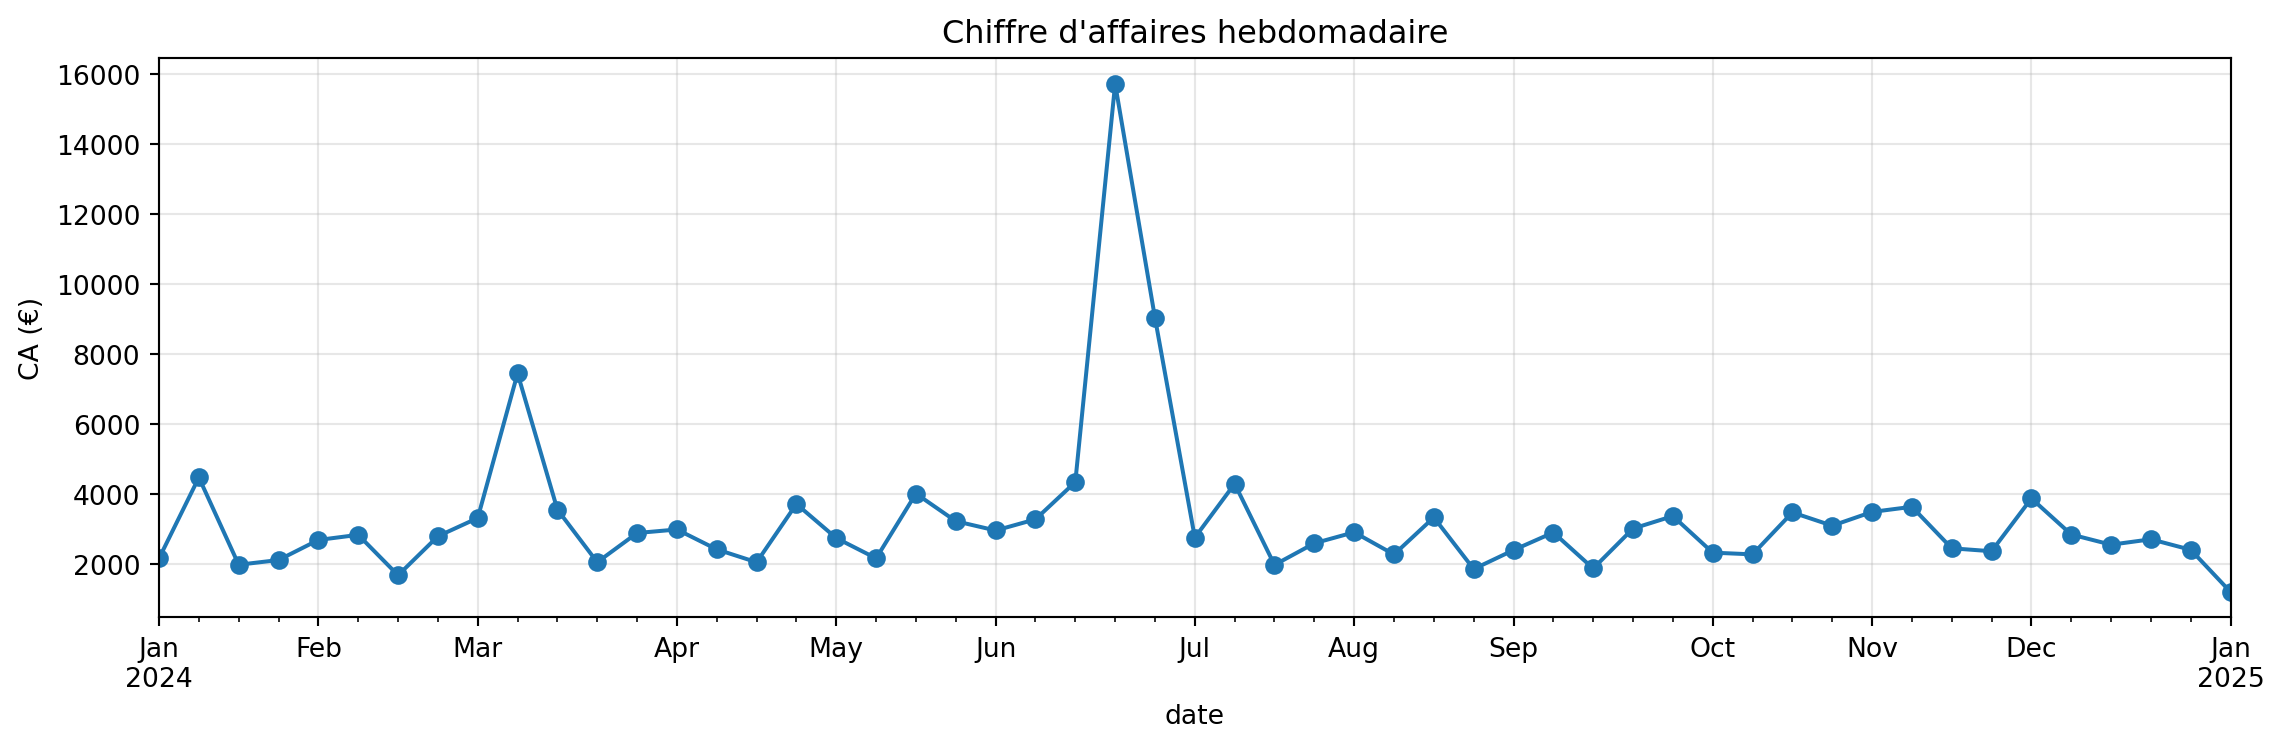

In [68]:
#| label: fig-ca-hebdo
#| fig-cap: Évolution hebdomadaire du CA
fig, ax = plt.subplots(figsize=(12, 4))
ca_hebdo.plot(ax=ax, marker="o", linewidth=1.5)
ax.set_title("Chiffre d'affaires hebdomadaire")
ax.set_ylabel("CA (€)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [69]:
#| eval: false
# TODO: Exercice bilan

In [70]:
# Chargement
df = pd.read_csv("ressources_tp/ventes_ecommerce.csv", parse_dates=["date"])
catalogue = pd.read_csv("ressources_tp/catalogue_produits.csv")

# === Nettoyage ===
# 1. Doublons
df = df.drop_duplicates().reset_index(drop=True)

# 2. Imputation
df["region"] = df["region"].fillna("Inconnue")
df["mode_paiement"] = df["mode_paiement"].fillna(df["mode_paiement"].mode()[0])

# 3. Normaliser catégorie
df["categorie"] = df["categorie"].str.capitalize()

# 4. Retirer les outliers de quantité
df = df[df["quantite"] <= 20].reset_index(drop=True)

print(f"Après nettoyage : {len(df)} transactions\n")

Après nettoyage : 1995 transactions



In [71]:
# === Analyses ===

# 5. KPIs globaux
print("=== KPIs globaux ===")
print(f"CA total       : {df['montant_total'].sum():,.2f} €")
print(f"Transactions   : {len(df):,}")
print(f"Panier moyen   : {df['montant_total'].mean():.2f} €")
print(f"Clients uniques: {df['id_client'].nunique()}")

=== KPIs globaux ===
CA total       : 146,406.86 €
Transactions   : 1,995
Panier moyen   : 73.39 €
Clients uniques: 300


In [72]:
# 6. Top 3 catégories avec %
ca_total = df["montant_total"].sum()
top_cat = (
    df.groupby("categorie")["montant_total"].sum()
    .sort_values(ascending=False).head(3)
)
top_cat_df = pd.DataFrame({
    "CA (€)": top_cat.round(0),
    "% du total": (top_cat / ca_total * 100).round(1)
})
print("=== Top 3 catégories ===")
print(top_cat_df)

=== Top 3 catégories ===
               CA (€)  % du total
categorie                        
Électronique  41177.0        28.1
Sport         34380.0        23.5
Vêtements     32727.0        22.4


In [73]:
# 7. Évolution mensuelle
ca_mois = df.groupby(df["date"].dt.month)["montant_total"].sum()
print("\n=== CA par mois ===")
print(ca_mois.round(0))
print(f"\nMeilleur mois : {ca_mois.idxmax()} ({ca_mois.max():,.0f} €)")
print(f"Pire mois     : {ca_mois.idxmin()} ({ca_mois.min():,.0f} €)")


=== CA par mois ===
date
1     11991.0
2     10736.0
3     11447.0
4     12047.0
5     11448.0
6     14526.0
7     12901.0
8     11389.0
9     11427.0
10    13604.0
11    12893.0
12    11998.0
Name: montant_total, dtype: float64

Meilleur mois : 6 (14,526 €)
Pire mois     : 2 (10,736 €)


In [74]:
# 8. Taux d'annulation par région
taux_annulation = (
    df.groupby("region")["statut"]
    .apply(lambda x: (x == "Annulée").mean() * 100)
    .sort_values(ascending=False)
    .round(2)
)
print("=== Taux d'annulation par région (%) ===")
print(taux_annulation)

=== Taux d'annulation par région (%) ===
region
Inconnue                10.00
Bretagne                 9.70
Hauts-de-France          7.27
PACA                     7.14
Île-de-France            6.56
Nouvelle-Aquitaine       6.49
Occitanie                5.49
Pays de la Loire         5.45
Auvergne-Rhône-Alpes     3.57
Grand Est                3.29
Name: statut, dtype: float64


In [75]:
# 9. Top 3 clients
top_clients = (
    df.groupby("id_client")
    .agg(ca=("montant_total", "sum"), nb_commandes=("id_transaction", "count"))
    .sort_values("ca", ascending=False)
    .head(3)
)
print("=== Top 3 clients ===")
print(top_clients.round(2))

=== Top 3 clients ===
                ca  nb_commandes
id_client                       
C0136      1397.01            12
C0012      1322.21            10
C0120      1301.36            12


In [76]:
# 10. CA par fournisseur
df_enrichi = df.merge(
    catalogue[["id_produit", "fournisseur"]],
    on="id_produit",
    how="left"
)

ca_fournisseur = (
    df_enrichi.groupby("fournisseur")["montant_total"]
    .sum().sort_values(ascending=False)
)
print("=== CA par fournisseur ===")
print(ca_fournisseur.round(0))

=== CA par fournisseur ===
fournisseur
Alpha SARL            61922.0
Beta Import           44573.0
Gamma Distribution    39913.0
Name: montant_total, dtype: float64
